# Semana 3 — Exploración inicial del dataset OULAD

En esta etapa se realiza una exploración inicial del dataset OULAD con el propósito de comprender la estructura de los datos, identificar variables relevantes y detectar posibles problemas de calidad de datos.

El análisis exploratorio constituye una fase fundamental dentro del desarrollo de modelos de Machine Learning, ya que permite conocer el comportamiento de la información antes del preprocesamiento y modelado.

## Importación de librerías

Se importan las librerías necesarias para la manipulación, análisis y visualización de datos.

In [641]:
# Librerías principales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Carga del dataset

Se carga el archivo `studentInfo.csv`, perteneciente al dataset OULAD, el cual contiene información académica y demográfica de estudiantes de educación superior en entornos virtuales de aprendizaje.

In [642]:
# Cargar dataset
df = pd.read_csv("../data/studentInfo.csv")

## Visualización inicial del dataset

Se muestran las primeras filas del conjunto de datos para comprender la estructura general de las variables.

In [643]:
# Ver primeras filas
df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


Las primeras filas permiten identificar la estructura general del dataset y observar variables relacionadas con características demográficas, académicas y resultados finales de los estudiantes.

## Dimensiones del dataset

Se analiza la cantidad de registros y variables presentes en el conjunto de datos.

In [644]:
# Dimensiones del dataset
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

Filas: 32593
Columnas: 12


El dataset contiene múltiples registros de estudiantes y diversas variables que podrán utilizarse para el análisis predictivo del rendimiento académico.

## Tipos de datos

Se identifican los tipos de datos de cada variable para determinar el tratamiento adecuado durante el preprocesamiento.

In [645]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   code_module           32593 non-null  object
 1   code_presentation     32593 non-null  object
 2   id_student            32593 non-null  int64 
 3   gender                32593 non-null  object
 4   region                32593 non-null  object
 5   highest_education     32593 non-null  object
 6   imd_band              31482 non-null  object
 7   age_band              32593 non-null  object
 8   num_of_prev_attempts  32593 non-null  int64 
 9   studied_credits       32593 non-null  int64 
 10  disability            32593 non-null  object
 11  final_result          32593 non-null  object
dtypes: int64(3), object(9)
memory usage: 3.0+ MB


Se observa la presencia de variables numéricas y categóricas. Además, algunas columnas presentan valores nulos, lo cual indica la necesidad de aplicar técnicas de limpieza y tratamiento de datos.

## Variables disponibles

Se muestran las variables disponibles dentro del dataset.

In [646]:
# Columnas
list(df.columns)

['code_module',
 'code_presentation',
 'id_student',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result']

Las variables disponibles incluyen información demográfica, nivel educativo, historial académico y resultado final del estudiante.

## Creación de la variable objetivo

La variable `final_result` será transformada en una variable binaria para abordar el problema como una tarea de clasificación supervisada.

Clasificación utilizada:

- 1 → Estudiantes aprobados (`Pass`, `Distinction`)
- 0 → Estudiantes no aprobados (`Fail`, `Withdrawn`)

In [647]:
# Crear variable objetivo binaria
df['target'] = df['final_result'].map({
    'Pass': 1,
    'Distinction': 1,
    'Fail': 0,
    'Withdrawn': 0
})

## Distribución de la variable objetivo

Se analiza la cantidad de estudiantes aprobados y no aprobados.

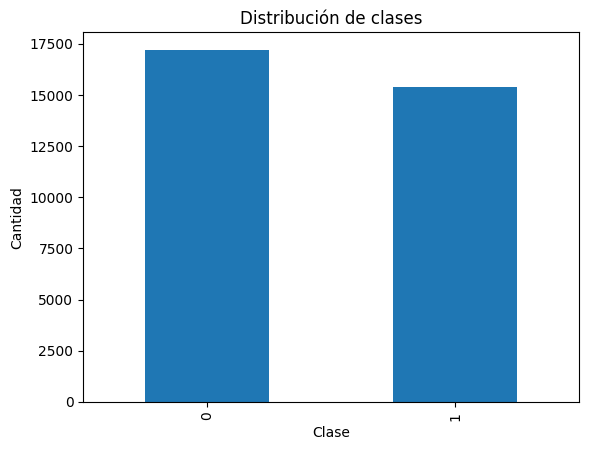

In [648]:
# Ver distribución de la variable objetivo
df['target'].value_counts().plot(kind='bar')

plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

La distribución de clases permite observar la proporción de estudiantes aprobados y no aprobados.

Este análisis es importante debido a que un desbalance significativo puede afectar el rendimiento de los modelos de Machine Learning.

## Verificación de valores nulos

Se identifican las variables que contienen datos faltantes dentro del dataset.

In [649]:
# Verificar valores nulos
df.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
target                     0
dtype: int64

Se identifico la variable ´imd_band´ con presencia de valores faltantes, el cual deberá ser tratado mediante técnicas de imputación o limpieza

## Estadísticas descriptivas

Se calculan estadísticas generales para comprender el comportamiento de las variables del dataset.

In [650]:
# Estadísticas descriptivas
df.describe(include='all')

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target
count,32593,32593,3.259300e+04,32593,32593,32593,31482,32593,32593.000000,32593.000000,32593,32593,32593.000000
unique,7,4,NaN,2,13,5,10,3,NaN,NaN,2,4,NaN
top,BBB,2014J,NaN,M,Scotland,A Level or Equivalent,20-30%,0-35,NaN,NaN,N,Pass,NaN
freq,7909,11260,NaN,17875,3446,14045,3654,22944,NaN,NaN,29429,12361,NaN
mean,NaN,NaN,7.066877e+05,NaN,NaN,NaN,NaN,NaN,0.163225,79.758691,NaN,NaN,0.472034
std,NaN,NaN,5.491673e+05,NaN,NaN,NaN,NaN,NaN,0.479758,41.071900,NaN,NaN,0.499225
min,NaN,NaN,3.733000e+03,NaN,NaN,NaN,NaN,NaN,0.000000,30.000000,NaN,NaN,0.000000
25%,NaN,NaN,5.085730e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,0.000000
50%,NaN,NaN,5.903100e+05,NaN,NaN,NaN,NaN,NaN,0.000000,60.000000,NaN,NaN,0.000000
75%,NaN,NaN,6.444530e+05,NaN,NaN,NaN,NaN,NaN,0.000000,120.000000,NaN,NaN,1.000000


Las estadísticas descriptivas permiten conocer características generales de las variables, incluyendo frecuencias, medias, valores máximos y mínimos.

Este análisis facilita la identificación preliminar de posibles valores atípicos o distribuciones no balanceadas.

# Conclusiones de la Semana 3

Durante esta etapa se realizó una exploración inicial del dataset OULAD, permitiendo comprender la estructura general de los datos y las variables disponibles para el análisis del rendimiento académico.

Además, se identificó la presencia de variables categóricas y numéricas, valores faltantes y una distribución específica de la variable objetivo, aspectos que deberán considerarse en las siguientes etapas del proyecto.

Este análisis inicial servirá como base para las fases posteriores de limpieza, análisis visual y preparación de datos para modelos de Machine Learning.

# Semana 4 — Limpieza básica y análisis descriptivo del dataset

En esta etapa se realiza la limpieza básica de los datos y un análisis descriptivo más detallado del dataset OULAD.

El objetivo es preparar la información para las siguientes fases del proyecto, identificando patrones, distribuciones y posibles problemas que puedan afectar el entrenamiento de modelos de Machine Learning.

## Limpieza básica de datos

Se realiza una preparación inicial del dataset eliminando variables irrelevantes y verificando posibles inconsistencias en los datos.

In [651]:
# Copia del dataset para trabajar
df_clean = df.copy()

### Eliminación de variables no relevantes

La variable `id_student` representa únicamente un identificador único de cada estudiante y no aporta valor predictivo para el análisis del rendimiento académico.

In [652]:
# Eliminar identificador de estudiante
df_clean = df_clean.drop(columns=['id_student'])

# Verificar columnas restantes
list(df_clean.columns)

['code_module',
 'code_presentation',
 'gender',
 'region',
 'highest_education',
 'imd_band',
 'age_band',
 'num_of_prev_attempts',
 'studied_credits',
 'disability',
 'final_result',
 'target']


La eliminación de variables irrelevantes ayuda a reducir ruido en los datos y facilita el análisis.

## Identificación de variables categóricas y numéricas

Se identifican los tipos de variables presentes en el dataset para determinar el tratamiento adecuado durante el preprocesamiento.

In [653]:
# Variables categóricas
categorical_cols = df_clean.select_dtypes(include='object').columns

# Variables numéricas
numerical_cols = df_clean.select_dtypes(exclude='object').columns

print("Variables categóricas:")
print(categorical_cols)

print("\nVariables numéricas:")
print(numerical_cols)

Variables categóricas:
Index(['code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'disability',
       'final_result'],
      dtype='object')

Variables numéricas:
Index(['num_of_prev_attempts', 'studied_credits', 'target'], dtype='object')


El dataset contiene variables categóricas relacionadas con información demográfica y académica, así como variables numéricas que representan características cuantitativas de los estudiantes.

## Análisis descriptivo de variables numéricas

Se calculan estadísticas descriptivas para comprender el comportamiento general de las variables numéricas.

In [654]:
# Estadísticas descriptivas de variables numéricas
df_clean[numerical_cols].describe()

,num_of_prev_attempts,studied_credits,target
count,32593.000000,32593.000000,32593.000000
mean,0.163225,79.758691,0.472034
std,0.479758,41.071900,0.499225
min,0.000000,30.000000,0.000000
25%,0.000000,60.000000,0.000000
50%,0.000000,60.000000,0.000000
75%,0.000000,120.000000,1.000000
max,6.000000,655.000000,1.000000


Las estadísticas descriptivas permiten identificar diferencias entre medias, máximos y mínimos, además de detectar posibles anomalías o valores extremos.

## Distribución de variables numéricas

Se analiza la distribución de las variables numéricas para identificar patrones, concentraciones de datos y posibles asimetrías.

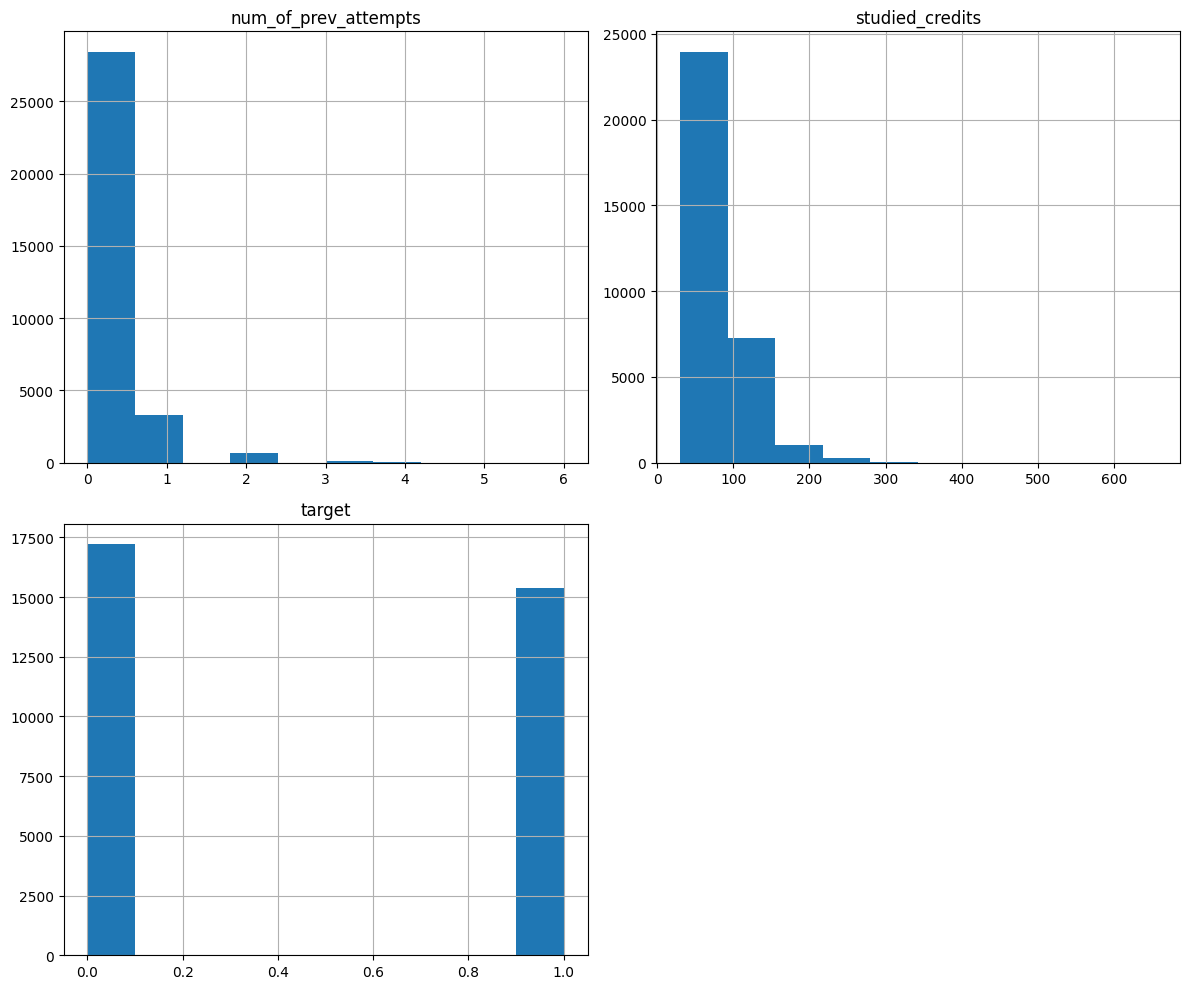

In [655]:
# Histogramas de variables numéricas
df_clean[numerical_cols].hist(figsize=(12,10))

plt.tight_layout()
plt.show()

Las distribuciones permiten observar el comportamiento general de las variables numéricas y detectar posibles sesgos o concentraciones de datos.

## Distribución de estudiantes según género

Se analiza la cantidad de estudiantes por género dentro del dataset.

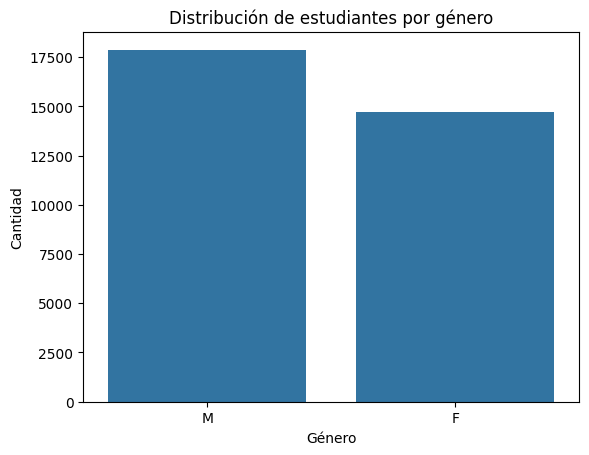

In [656]:
# Distribución por género
#print(df_clean['gender'].value_counts())

sns.countplot(x='gender', data=df_clean)

plt.title('Distribución de estudiantes por género')
plt.xlabel('Género')
plt.ylabel('Cantidad')

plt.show()

La distribución de género permite conocer la composición demográfica de los estudiantes incluidos en el dataset.

## Distribución según nivel educativo

Se analiza la distribución de estudiantes según su nivel educativo previo.

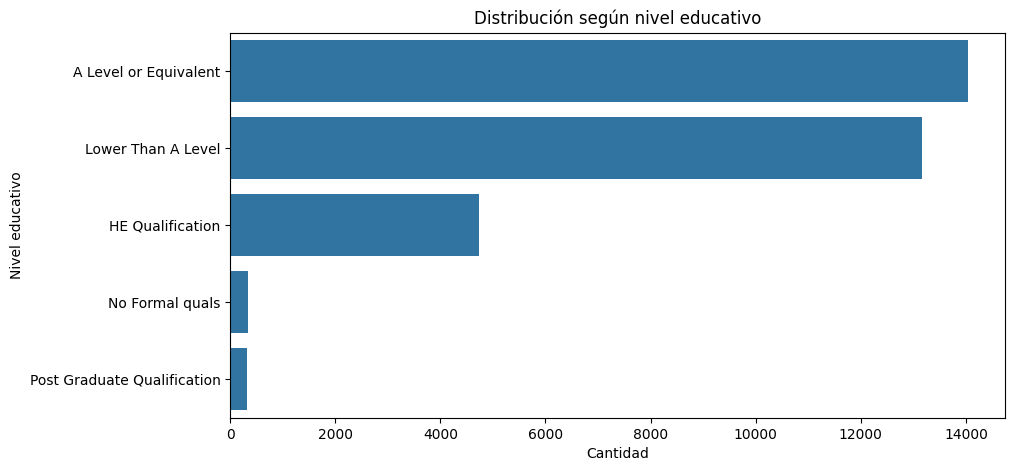

In [657]:
# Distribución por nivel educativo
plt.figure(figsize=(10,5))

sns.countplot(
    y='highest_education',
    data=df_clean,
    order=df_clean['highest_education'].value_counts().index
)

plt.title('Distribución según nivel educativo')
plt.xlabel('Cantidad')
plt.ylabel('Nivel educativo')

plt.show()

El nivel educativo previo puede influir en el rendimiento académico, por lo que esta variable podría ser relevante en etapas posteriores del modelado.

## Distribución de intentos previos

Se analiza la cantidad de intentos previos realizados por los estudiantes.

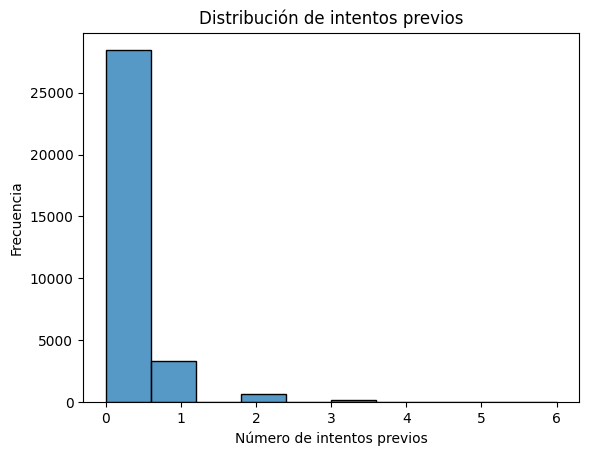

In [658]:
# Distribución de intentos previos
sns.histplot(df_clean['num_of_prev_attempts'], bins=10)

plt.title('Distribución de intentos previos')
plt.xlabel('Número de intentos previos')
plt.ylabel('Frecuencia')

plt.show()

La mayoría de estudiantes presentan pocos intentos previos, aunque existen algunos casos con múltiples repeticiones, lo que podría relacionarse con el rendimiento académico.

## Distribución de créditos estudiados

Se analiza la distribución de créditos cursados por los estudiantes.

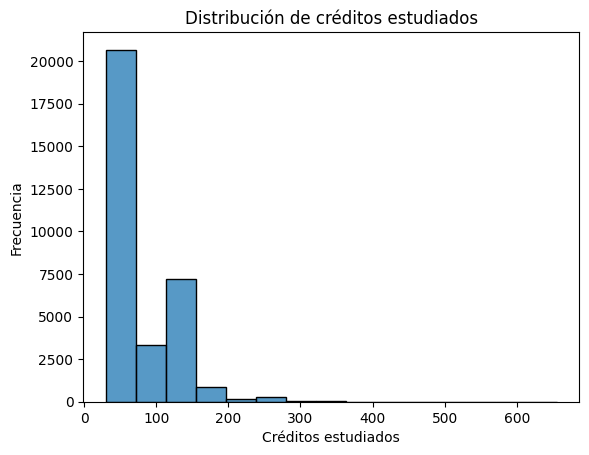

In [659]:
# Distribución de créditos estudiados
sns.histplot(df_clean['studied_credits'], bins=15)

plt.title('Distribución de créditos estudiados')
plt.xlabel('Créditos estudiados')
plt.ylabel('Frecuencia')

plt.show()

La variable de créditos estudiados presenta diferentes concentraciones de estudiantes, lo que podría reflejar distintas cargas académicas.

## Relación entre género y rendimiento académico

Se analiza la relación entre el género y la variable objetivo.

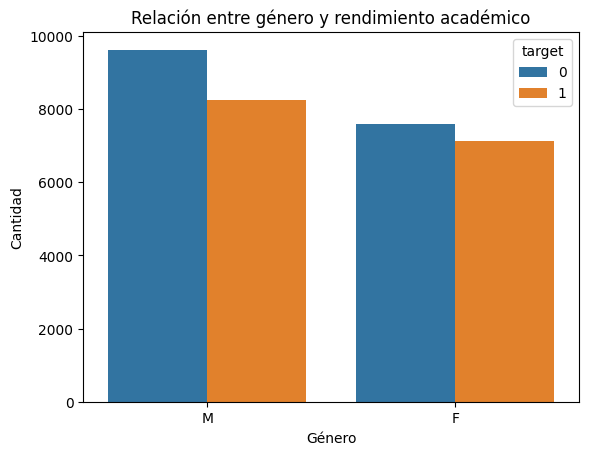

In [660]:
# Relación entre género y target
sns.countplot(x='gender', hue='target', data=df_clean)

plt.title('Relación entre género y rendimiento académico')
plt.xlabel('Género')
plt.ylabel('Cantidad')

plt.show()

Se observan diferencias en la distribución del rendimiento académico según el género.

## Relación entre nivel educativo y rendimiento académico

Se analiza la relación entre el nivel educativo y la variable objetivo.

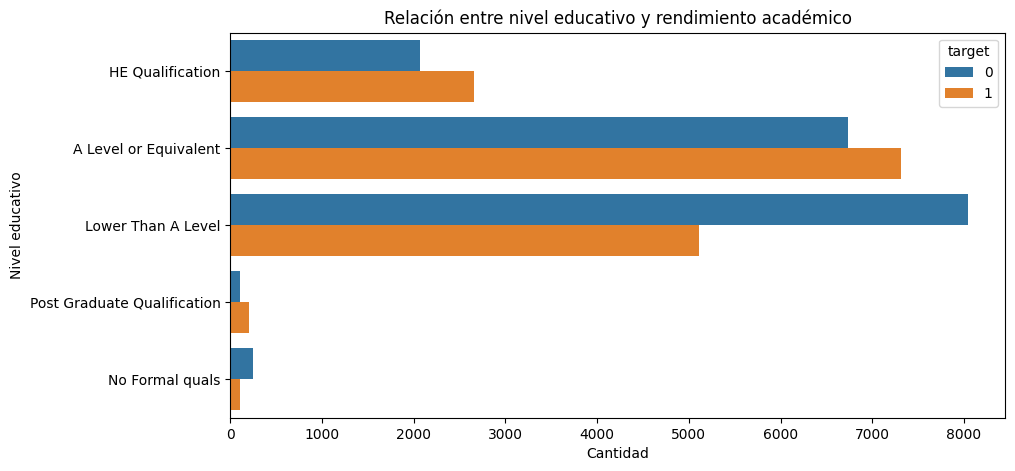

In [661]:
# Relación entre nivel educativo y target
plt.figure(figsize=(10,5))

sns.countplot(
    y='highest_education',
    hue='target',
    data=df_clean
)

plt.title('Relación entre nivel educativo y rendimiento académico')
plt.xlabel('Cantidad')
plt.ylabel('Nivel educativo')

plt.show()

El nivel educativo previo podría influir en la probabilidad de aprobación o reprobación de los estudiantes.

# Conclusiones de la Semana 4

Durante esta etapa se realizó una limpieza básica del dataset y un análisis descriptivo de las variables académicas y demográficas.

Los análisis permitieron identificar patrones en la distribución de variables, posibles relaciones entre características estudiantiles y rendimiento académico, así como diferencias en la composición de los datos.

Estos resultados servirán como base para las etapas posteriores de análisis de correlación, detección de valores atípicos y preparación final de los datos para el entrenamiento de modelos de Machine Learning.

# Semana 5 — Análisis avanzado y preparación final de datos

En esta etapa se realiza un análisis más profundo de las relaciones entre variables, detección de valores atípicos, análisis de correlación y codificación de variables categóricas.

El objetivo es preparar el dataset para las siguientes fases del proyecto relacionadas con el entrenamiento y evaluación de modelos de Machine Learning.

## Relación entre intentos previos y rendimiento académico

Se analiza la relación entre el número de intentos previos y el rendimiento académico de los estudiantes.

Text(0.5, 1.0, 'Relación entre intentos previos y éxito académico')

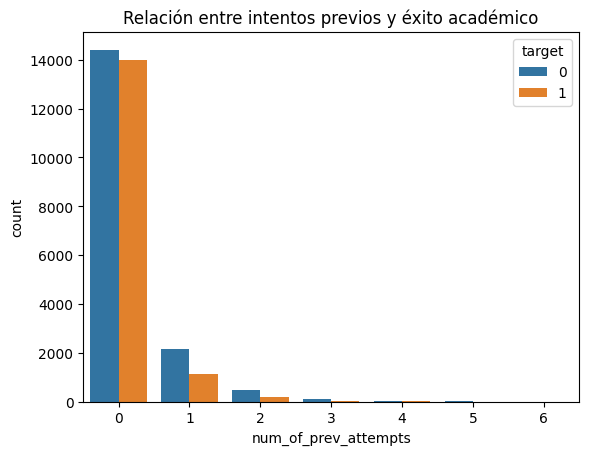

In [662]:
# Relación entre intentos previos y target
sns.countplot(x='num_of_prev_attempts', hue='target', data=df_clean)
plt.title('Relación entre intentos previos y éxito académico')

Los estudiantes con mayor cantidad de intentos previos podrían presentar una mayor probabilidad de bajo rendimiento académico.

## Relación entre créditos estudiados y rendimiento académico

Se analiza la relación entre la cantidad de créditos estudiados y la variable objetivo.

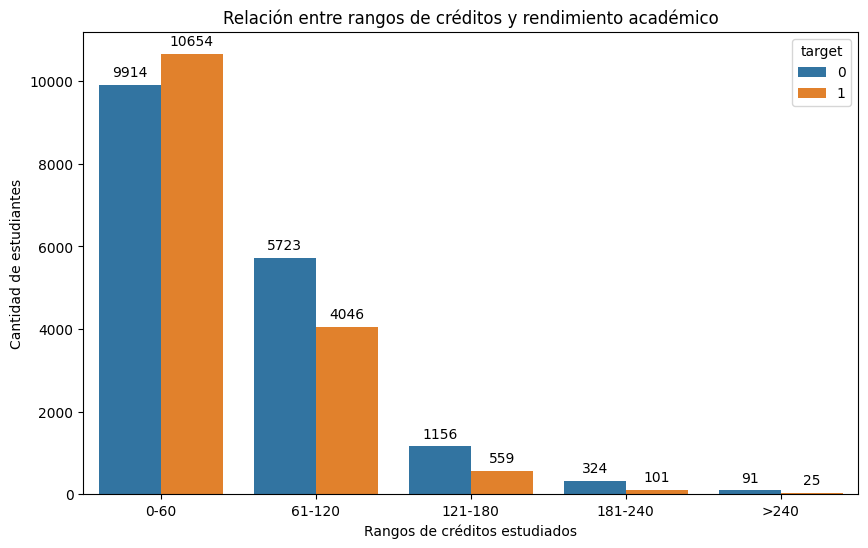

In [663]:
# Relación entre créditos estudiados y rendimiento académico
df_clean['credits_range'] = pd.cut(df_clean['studied_credits'], 
                                   bins=[0, 60, 120, 180, 240, 1000], 
                                   labels=['0-60', '61-120', '121-180', '181-240', '>240'])

# 2. Configurar la gráfica
plt.figure(figsize=(10, 6))

# Al no especificar 'palette', Seaborn usará los colores azul y naranja por defecto
ax = sns.countplot(x='credits_range', hue='target', data=df_clean)

# Añadir etiquetas de datos sobre las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title('Relación entre rangos de créditos y rendimiento académico')
plt.xlabel('Rangos de créditos estudiados')
plt.ylabel('Cantidad de estudiantes')
plt.legend(title='target', labels=['0', '1'])

plt.show()

Se observa que los estudiantes con un rendimiento negativo (Target 0) presentan una dispersión mayor en la cantidad de créditos inscritos, incluyendo casos extremos de hasta 600 créditos, lo que sugiere que la carga académica es una variable predictiva importante para el modelo.

## Identificación de valores atípicos (Outliers)

Se analizan posibles valores extremos en variables numéricas que podrían afectar el entrenamiento de modelos de Machine Learning.

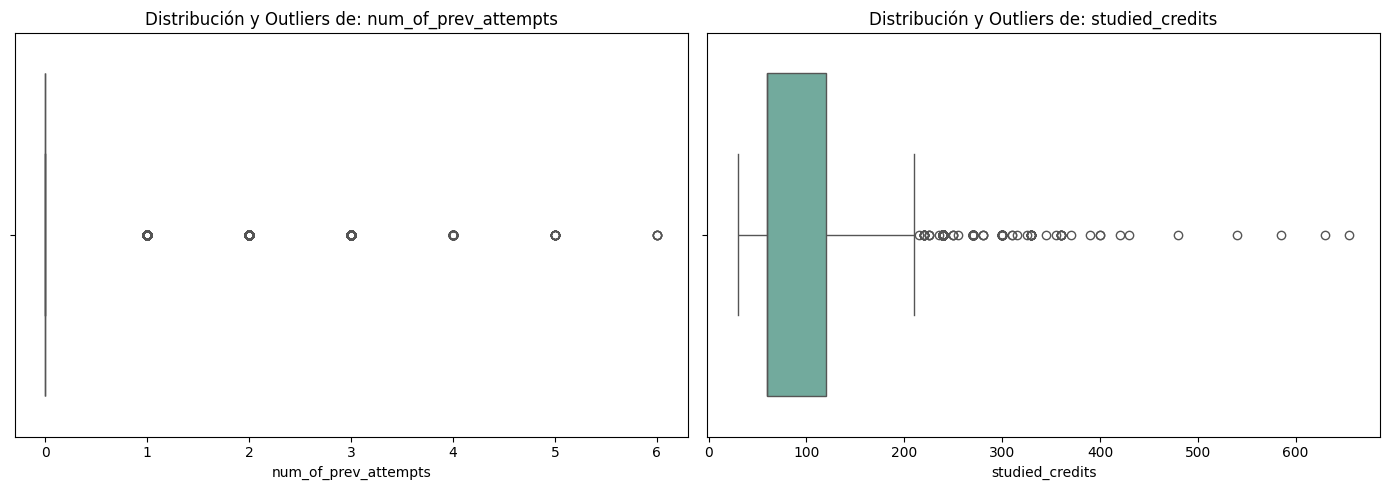

In [664]:
# Variables numéricas
# Excluimos 'target' porque es nuestra variable objetivo binaria
cols_para_analisis = ['num_of_prev_attempts', 'studied_credits']

plt.figure(figsize=(14, 5))

for i, col in enumerate(cols_para_analisis):
    plt.subplot(1, 2, i + 1)
    
    # Usamos color fijo en lugar de palette para evitar el error y mantener la caja
    sns.boxplot(x=df_clean[col], color="#69b3a2") 
    
    plt.title(f'Distribución y Outliers de: {col}')
    plt.xlabel(col)

plt.tight_layout()
plt.show()

Se identifican posibles valores atípicos en algunas variables numéricas.

## Codificación de variables categóricas

Las variables categóricas son transformadas a formato numérico para permitir su utilización en algoritmos de Machine Learning.

In [665]:
# Codificación One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Ver dimensiones del dataset codificado
df_encoded.shape

(32593, 48)

La codificación transforma variables categóricas en representaciones numéricas que pueden ser interpretadas por los modelos de Machine Learning.

## Análisis de correlación

Se analiza la relación entre variables numéricas para identificar posibles asociaciones relevantes con el rendimiento académico.

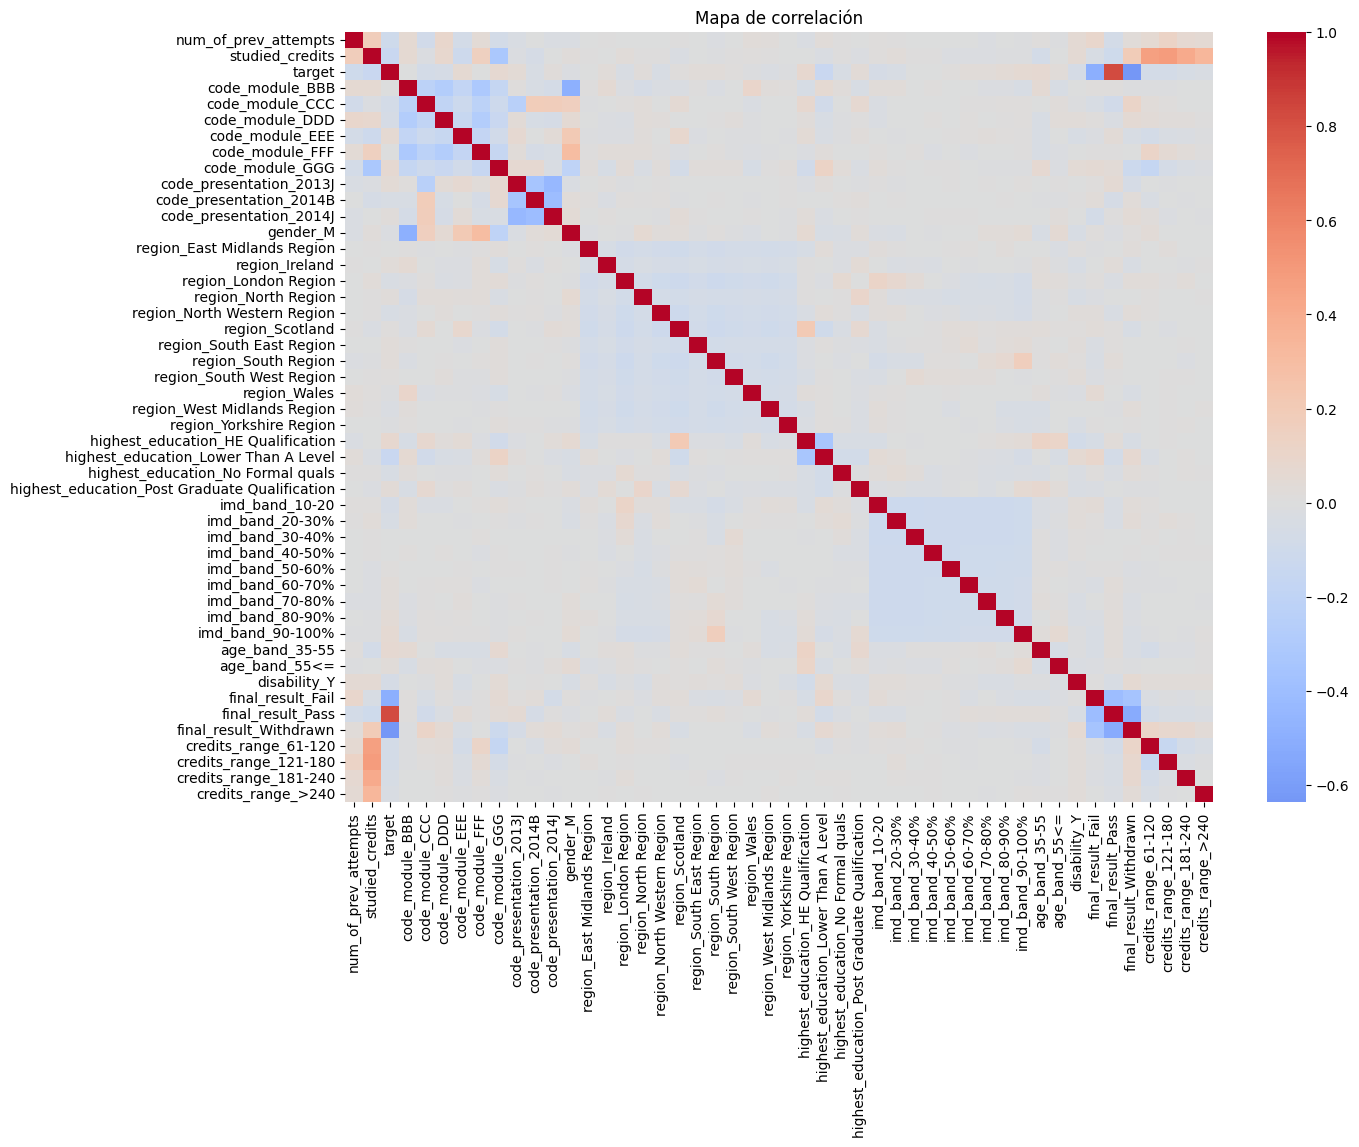

In [666]:
# Matriz de correlación
corr = df_encoded.corr(numeric_only=True)

# Tamaño de figura
plt.figure(figsize=(14,10))

# Heatmap
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Mapa de correlación')

plt.show()

El análisis de correlación permite identificar variables con posibles relaciones respecto al rendimiento académico, lo cual puede influir en el desempeño de los modelos predictivos.

## Variables con mayor correlación respecto al target

Se identifican las variables con mayor relación respecto a la variable objetivo.

In [667]:
# Correlación respecto al target
target_corr = corr['target'].sort_values(ascending=False)

# Mostrar correlaciones más relevantes
target_corr.head(10)

target                                           1.000000
final_result_Pass                                0.826654
highest_education_HE Qualification               0.074032
code_module_GGG                                  0.072957
age_band_35-55                                   0.063331
imd_band_90-100%                                 0.060095
code_module_EEE                                  0.056916
imd_band_80-90%                                  0.041762
code_presentation_2013J                          0.041445
highest_education_Post Graduate Qualification    0.036081
Name: target, dtype: float64

Las variables con mayor correlación respecto al target podrían representar características importantes para la predicción del rendimiento académico.

## Preparación final del dataset

Se prepara el dataset final que será utilizado en las siguientes etapas de modelado y evaluación de algoritmos de Machine Learning.

In [668]:
# Verificar dimensiones finales
print(f"Dimensiones finales: {df_encoded.shape}")

# Verificar datos finales
df_encoded.head()

Dimensiones finales: (32593, 48)


,num_of_prev_attempts,studied_credits,target,code_module_BBB,code_module_CCC,code_module_DDD,code_module_EEE,code_module_FFF,code_module_GGG,code_presentation_2013J,...,age_band_35-55,age_band_55<=,disability_Y,final_result_Fail,final_result_Pass,final_result_Withdrawn,credits_range_61-120,credits_range_121-180,credits_range_181-240,credits_range_>240
0,0,240,1,False,False,False,False,False,False,True,...,False,True,False,False,True,False,False,False,True,False
1,0,60,1,False,False,False,False,False,False,True,...,True,False,False,False,True,False,False,False,False,False
2,0,60,0,False,False,False,False,False,False,True,...,True,False,True,False,False,True,False,False,False,False
3,0,60,1,False,False,False,False,False,False,True,...,True,False,False,False,True,False,False,False,False,False
4,0,60,1,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False


El dataset final ya se encuentra preparado para las siguientes fases del proyecto relacionadas con entrenamiento, validación y evaluación de modelos predictivos.

## Exportación del dataset preparado

Se guarda el dataset procesado y codificado para ser utilizado en las siguientes etapas del proyecto relacionadas con el entrenamiento y evaluación de modelos de Machine Learning.

La exportación del dataset preparado permite reutilizar la información procesada en etapas posteriores del proyecto, garantizando organización y reproducibilidad del análisis.

In [ ]:
# Guardar dataset preparado
df_encoded.to_csv("../data-preparada/dataset_preparado.csv", index=False)

print("Dataset preparado guardado correctamente.")

# Conclusiones de la Semana 5

Durante esta etapa se realizó un análisis avanzado del dataset OULAD, incluyendo relaciones entre variables, identificación de valores atípicos, análisis de correlación y codificación de variables categóricas.

Los resultados obtenidos permitieron identificar características potencialmente relevantes para la predicción del rendimiento académico y preparar el conjunto de datos para las etapas posteriores de modelado.